In [6]:
# =========================
# LOAD DATA (ROBUST)
# =========================

from pathlib import Path
import pandas as pd

FILE_PATH = Path("../data/processed/eda_only_features/eda_features_all.csv")

print("Current working dir:", Path.cwd())
print("Trying to load:", FILE_PATH)

# ---- Check if file exists ----
if not FILE_PATH.exists():
    print("\n❌ File not found!")
    print("Available CSV files instead:\n")
    
    for p in Path.cwd().glob("**/*.csv"):
        print(p)
        
else:
    print("\n✅ File found")

    # ---- Try loading ----
    try:
        df = pd.read_csv(FILE_PATH)
    except:
        print("⚠️ Trying with semicolon separator...")
        df = pd.read_csv(FILE_PATH, sep=";")

    # ---- Basic info ----
    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nDescribe before log and clipping:")

    print("\nDescribe SCRR:")
    print(df["SC_RR"].describe())

    print("\nDescribe SC_PH:")
    print(df["SC_PH"].describe())

    print("\nDescribe EDA_slope:")
    print(df["EDA_slope"].describe())

Current working dir: c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\notebooks
Trying to load: ..\data\processed\eda_only_features\eda_features_all.csv

✅ File found

Shape: (7124, 5)

Columns:
['SC_PH', 'SC_RR', 'EDA_slope', 'participant', 'time_sec']

Describe before log and clipping:

Describe SCRR:
count    7124.000000
mean        0.074743
std         0.064866
min         0.000000
25%         0.016667
50%         0.066667
75%         0.116667
max         0.366667
Name: SC_RR, dtype: float64

Describe SC_PH:
count    7.124000e+03
mean     2.928562e+05
std      4.325916e+06
min      2.406981e-03
25%      6.226941e-01
50%      2.536803e+00
75%      1.009853e+01
max      1.341047e+08
Name: SC_PH, dtype: float64

Describe EDA_slope:
count    7124.000000
mean        0.000068
std         0.000206
min        -0.000287
25%        -0.000146
50%         0.000136
75%         0.000269
max         0.000289
Name: EDA_slope, dtype: float64


In [2]:
import numpy as np

features = ["SC_PH", "SC_RR", "EDA_slope"]

# --- SC_PH ---
df["SC_PH"] = np.log1p(df["SC_PH"])
low, high = df["SC_PH"].quantile([0.01, 0.99])
df["SC_PH"] = df["SC_PH"].clip(low, high)

# --- SC_RR ---
low, high = df["SC_RR"].quantile([0.01, 0.99])
df["SC_RR"] = df["SC_RR"].clip(low, high)

# --- SLOPE ---
low, high = df["EDA_slope"].quantile([0.01, 0.99])
df["EDA_slope"] = df["EDA_slope"].clip(low, high)

features_df = features_df[features_df["RR_quality"] > 0.7]

print("\nDescribe AFTER log and clipping:")

print("\nDescribe SCRR:")
print(df["SC_RR"].describe())

print("\nDescribe SC_PH:")
print(df["SC_PH"].describe())

print("\nDescribe EDA_slope:")
print(df["EDA_slope"].describe())

NameError: name 'features_df' is not defined

In [7]:
def evaluate_eda_features(df, features, participant_col="participant"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    report = {}

    print("\n==============================")
    print("EDA FEATURE EVALUATION REPORT")
    print("==============================")

    # =========================
    # 1. DISTRIBUTION ANALYSIS
    # =========================
    print("\n=== DISTRIBUTIONS ===")
    for f in features:
        print(f"\nFeature: {f}")
        skew = df[f].skew()
        kurt = df[f].kurtosis()

        print(f"Skewness: {skew:.3f}")
        print(f"Kurtosis: {kurt:.3f}")

        report[f] = {
            "skew": float(skew),
            "kurtosis": float(kurt)
        }

        plt.figure()
        df[f].hist(bins=50)
        plt.title(f"{f} (Skew={skew:.2f})")
        plt.show()

    # =========================
    # 2. OUTLIER DETECTION (IQR)
    # =========================
    print("\n=== OUTLIERS (IQR) ===")
    for f in features:
        Q1 = df[f].quantile(0.25)
        Q3 = df[f].quantile(0.75)
        IQR = Q3 - Q1

        outliers = df[(df[f] < Q1 - 1.5*IQR) | (df[f] > Q3 + 1.5*IQR)]
        ratio = len(outliers) / len(df)

        print(f"{f} outlier ratio: {ratio:.3f}")
        report[f]["outlier_ratio"] = float(ratio)

    # =========================
    # 3. CORRELATION MATRIX
    # =========================
    print("\n=== CORRELATIONS ===")
    corr = df[features].corr()
    print(corr)

    plt.figure()
    plt.imshow(corr, interpolation='nearest')
    plt.colorbar()
    plt.xticks(range(len(features)), features)
    plt.yticks(range(len(features)), features)
    plt.title("Feature Correlation Matrix")
    plt.show()

    report["correlation_matrix"] = corr.to_dict()

    # =========================
    # 4. PARTICIPANT VARIABILITY
    # =========================
    print("\n=== BETWEEN-PARTICIPANT VARIATION ===")
    group_means = df.groupby(participant_col)[features].mean()

    for f in features:
        std_between = group_means[f].std()
        std_total = df[f].std()

        ratio = std_between / std_total if std_total > 0 else 0

        print(f"{f}: between/total std = {ratio:.3f}")
        report[f]["between_subject_ratio"] = float(ratio)

    # =========================
    # 5. FEATURE SIGNAL QUALITY SCORE
    # =========================
    print("\n=== FEATURE QUALITY SCORE ===")

    for f in features:
        score = 0

        # låg outlier ratio är bra
        if report[f]["outlier_ratio"] < 0.05:
            score += 1

        # rimlig skewness
        if abs(report[f]["skew"]) < 2:
            score += 1

        # variation mellan personer (bra för ML)
        if report[f]["between_subject_ratio"] > 0.3:
            score += 1

        print(f"{f} score: {score}/3")
        report[f]["quality_score"] = score

    return report


EDA FEATURE EVALUATION REPORT

=== DISTRIBUTIONS ===

Feature: SC_PH
Skewness: 0.368
Kurtosis: 0.570


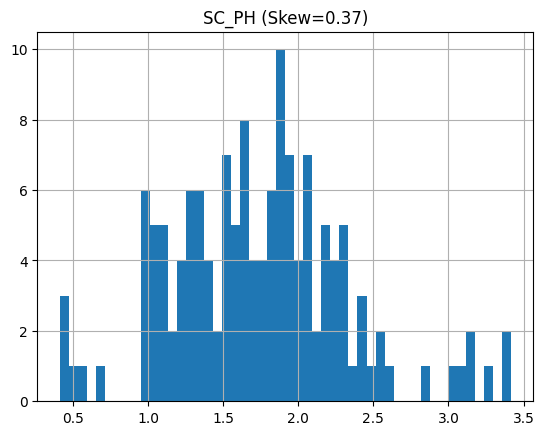


Feature: SC_RR
Skewness: 0.831
Kurtosis: 0.709


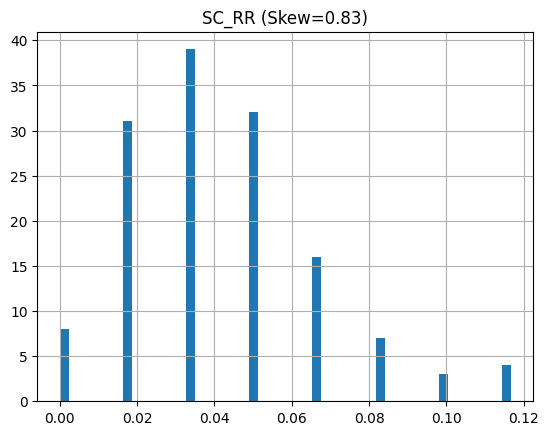


Feature: EDA_slope
Skewness: -0.260
Kurtosis: -1.406


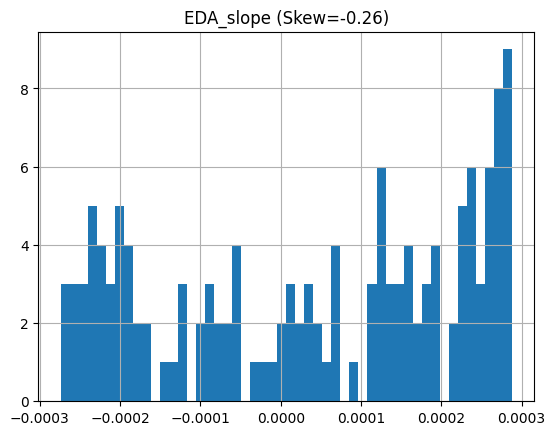


=== OUTLIERS (IQR) ===
SC_PH outlier ratio: 0.029
SC_RR outlier ratio: 0.029
EDA_slope outlier ratio: 0.000

=== CORRELATIONS ===
              SC_PH     SC_RR  EDA_slope
SC_PH      1.000000  0.814246  -0.487799
SC_RR      0.814246  1.000000  -0.444265
EDA_slope -0.487799 -0.444265   1.000000


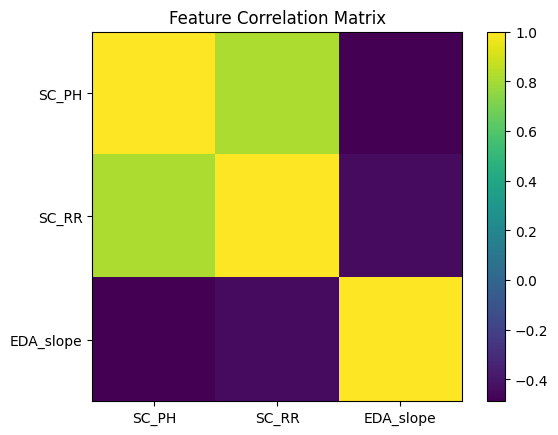


=== BETWEEN-PARTICIPANT VARIATION ===
SC_PH: between/total std = nan
SC_RR: between/total std = nan
EDA_slope: between/total std = nan

=== FEATURE QUALITY SCORE ===
SC_PH score: 2/3
SC_RR score: 2/3
EDA_slope score: 2/3


In [4]:
features = ["SC_PH", "SC_RR", "EDA_slope"]

report = evaluate_eda_features(df, features)

In [5]:
df.describe()

,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,time_sec,SC_PH,SC_RR,EDA_slope
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.0,140.000000,140.000000,140.000000,140.000000
mean,93.120470,34.222876,34.194649,46.058648,644.635844,45.809487,536.321429,790.785714,93.035714,0.984155,1.0,1042.500000,1.736652,0.041667,0.000041
std,2.030836,6.934630,6.892080,13.606694,14.288909,13.529155,45.334928,102.890372,2.075589,0.042035,0.0,608.378994,0.594116,0.025874,0.000188
min,86.192327,22.507309,22.505770,26.773034,615.106383,26.630244,405.000000,685.000000,85.000000,0.795699,1.0,0.000000,0.412110,0.000000,-0.000274
25%,92.046054,29.431804,29.430319,37.432517,636.398236,37.229065,535.000000,730.000000,92.000000,1.000000,1.0,521.250000,1.318604,0.016667,-0.000140
50%,93.275961,32.488724,32.485931,42.538490,643.252688,42.312816,550.000000,755.000000,93.000000,1.000000,1.0,1042.500000,1.736969,0.033333,0.000071
75%,94.280588,37.243805,37.230335,48.905496,651.847826,48.641119,560.000000,795.000000,94.000000,1.000000,1.0,1563.750000,2.048672,0.050000,0.000226
max,97.544102,54.957203,54.898964,87.699366,696.117647,87.193890,590.000000,1095.000000,97.000000,1.000000,1.0,2085.000000,3.415014,0.116667,0.000288


In [ ]:
df[df["SC_PH"] > 10]
df[df["EDA_slope"] < -0.1]